In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
import numpy as np
import xarray as xr

from causaldynamics.scm import create_scm_graph
from causaldynamics.plot import plot_scm
from causaldynamics.score import score
from causaldynamics.baselines import PCMCIPlus
from causaldynamics.baselines import FPCMCI
from causaldynamics.baselines import DYNOTEARS
from causaldynamics.baselines import VARLiNGAM
from causaldynamics.baselines import NGC_LSTM
from causaldynamics.baselines import TSCI
from causaldynamics.baselines import CUTSPlus
# from causaldynamics.baselines import RCD
# from causaldynamics.baselines import GIN
# from causaldynamics.baselines import GRASP
from causaldynamics.baselines import TCDF

# DYNOTEARS / FPCMCI + not sure about PCMCIPlus + VARLiNGAM

from tqdm import tqdm
from pathlib import Path
import torch

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt 

In [3]:
from causaldynamics.baselines import PICABU, StructuredLowRankDiscovery, StructuredODEDiscovery

In [4]:
noise = 1.00
f"/home/mila/j/julien.boussard/scratch/CausalDynamics/data/simple/noise={noise:.2f}_confounder=True/data"


'/home/mila/j/julien.boussard/scratch/CausalDynamics/data/simple/noise=1.00_confounder=True/data'

In [24]:
len(all_files)

59

In [5]:
import glob 

all_files = glob.glob("../data/simple/noise=2.00_confounder=True/data/*")
for file in all_files:
    print(file.split("/")[-1])

Arneodo_N10_T1000.nc
SprottE_N10_T1000.nc
SprottM_N10_T1000.nc
Chen_N10_T1000.nc
KawczynskiStrizhak_N10_T1000.nc
SprottS_N10_T1000.nc
ThomasLabyrinth_N10_T1000.nc
Hadley_N10_T1000.nc
SprottTorus_N10_T1000.nc
PehlivanWei_N10_T1000.nc
SprottC_N10_T1000.nc
SprottQ_N10_T1000.nc
SprottP_N10_T1000.nc
SprottL_N10_T1000.nc
SprottH_N10_T1000.nc
DequanLi_N10_T1000.nc
Thomas_N10_T1000.nc
RayleighBenard_N10_T1000.nc
Duffing_N10_T1000.nc
SprottN_N10_T1000.nc
ChenLee_N10_T1000.nc
Tsucs2_N10_T1000.nc
Finance_N10_T1000.nc
Chua_N10_T1000.nc
LiuChen_N10_T1000.nc
SprottA_N10_T1000.nc
SprottK_N10_T1000.nc
SprottD_N10_T1000.nc
LuChenCheng_N10_T1000.nc
Sakarya_N10_T1000.nc
YuWang2_N10_T1000.nc
Lorenz_N10_T1000.nc
Coullet_N10_T1000.nc
BurkeShaw_N10_T1000.nc
Halvorsen_N10_T1000.nc
RikitakeDynamo_N10_T1000.nc
SprottF_N10_T1000.nc
SprottI_N10_T1000.nc
YuWang_N10_T1000.nc
Rucklidge_N10_T1000.nc
SprottG_N10_T1000.nc
SanUmSrisuchinwong_N10_T1000.nc
PanXuZhou_N10_T1000.nc
Laser_N10_T1000.nc
ZhouChen_N10_T1000.nc
Sp

In [6]:
# Once you have the dataset, either generated or downloaded
# Notice that the dataset has `time_series` and `adjacency_matrix` variables.
# DATA_DIR = Path("../data/simple/noise=0.00_confounder=False/data")  # (you can change this to your own path)
# ds = xr.open_dataset(DATA_DIR / "Chen_N10_T1000.nc")

DATA_DIR = Path("../data/simple/noise=0.00_confounder=False/data")  # (you can change this to your own path)
ds = xr.open_dataset(DATA_DIR / "Rossler_N10_T1000.nc")

# # Extract timeseries and adjacency matrix as target # If not coupled
timeseries = ds['time_series'].to_numpy().transpose(1, 0, 2) # shape of (N, T, D)
adj_matrix = ds['adjacency_matrix'].to_numpy()

# DATA_DIR = Path("../data/coupled/coupling=linear_noise=0.00_systems=10_confounder=False_standardize=False_timelag=0_activation=mixed/data")  # (you can change this to your own path)
# ds = xr.open_dataset(DATA_DIR / "SRAYLEIGHBENARD_N10_T1000_seed0.nc")

# # NOTE: If dataset is from coupled system e.g., "../data/coupled/...", follow these changes to load the data:
# timeseries = ds['time_series'].to_numpy()[..., 0].transpose(1, 0, 2) ## select the first dimension of each multidimensional node
# adj_matrix = ds['adjacency_matrix_summary'].to_numpy() ## `adjacency_matrix_summary` is the true adjacency matrix for coupled system


In [7]:
adj_matrix

array([[0, 1, 1],
       [1, 1, 0],
       [1, 0, 1]])

In [8]:
# RESULTS_DIR = Path("../data/simple/noise=0.00_confounder=False/eval/tcdf")  # (you can change this to your own path)
# ds = xr.open_dataset(DATA_DIR / "Rossler_N10_T1000.nc")


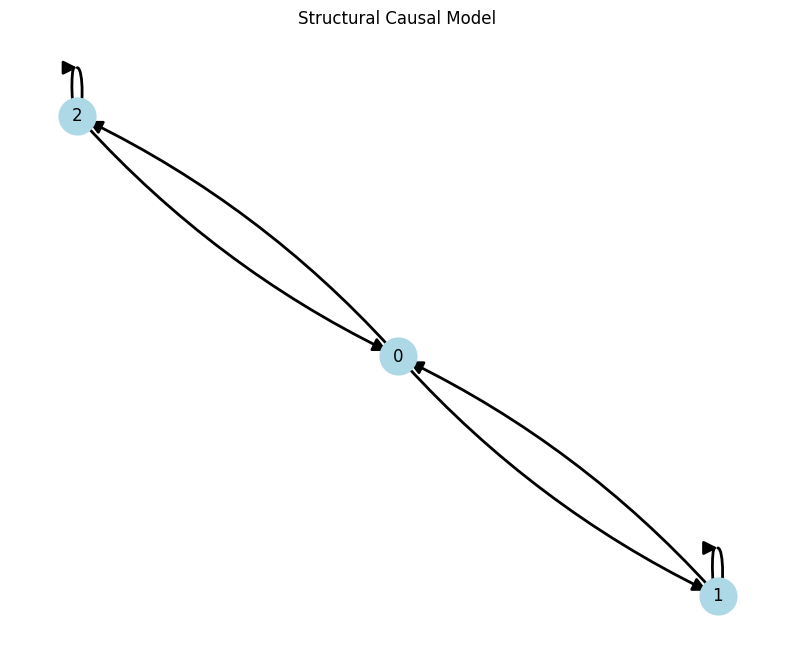

In [9]:
G = create_scm_graph(adj_matrix)
plot_scm(G);


In [10]:
tau = 0
T = timeseries.shape[1]
D = timeseries.shape[-1]
timeseries_stacked = np.stack([np.stack([timeseries[k, i:i + tau + 1] for i in range(T - tau)]) for k in range(timeseries.shape[0])])
timeseries_stacked.shape

(10, 1000, 1, 3)

In [11]:
# np.any(np.isnan(timeseries_stacked[0, :, 0]), axis = 1)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
timeseries_stacked.shape

(10, 1000, 1, 3)

In [20]:
tau_max = 1 # i.e. no delay 

## Estimate adjacency matrix
lowrank_adj_matrix = []

for x in [timeseries[:, :, None][0]]:
    lowrank_model = StructuredODEDiscovery(
        t = tau_max,
        n = 3,
        L_lipschitz = 1, 
        is_lipschitz = False,
        hidden_dim = 32, 
        n_layers = 2,
        device = device,
    )
    trained_model, mask = lowrank_model.run(X=torch.tensor(x).to(device), l0_l1_l2='l0', th=0.5, lr=0.001, lambda_grad=100, lambda_m = 0.001, n_inner_min_sparse = 100, batch_size=32, n_inner=4_000, patience = 200)
    lowrank_adj_matrix.append(mask.detach().cpu().numpy())
#     lowrank_S_matrix.append(copy.deepcopy(lowrank_model.model.S))



Dimensions: N=3, T=1
Number of NaN values in X: False
Number of NaN values after normalization in X: False
Constant dimensions in X: (tensor([], device='cuda:0', dtype=torch.int64),)
  → stopping inner loop at step 1151 after 200 no-improve steps (best=0.002000, current=0.002139)
recon=0.0013  |M|_1=5.990  grad_penalty=0.0000  


In [21]:
mask

tensor([[[9.0195e-06, 9.9749e-01, 9.9600e-01],
         [9.9734e-01, 5.9243e-04, 9.9326e-01],
         [9.9558e-01, 4.8985e-06, 9.9615e-01]]], device='cuda:0',
       grad_fn=<SigmoidBackward0>)

In [22]:
adj_matrix

array([[0, 1, 1],
       [1, 1, 0],
       [1, 0, 1]])

In [23]:
results_scores = score(
    preds= (np.array(lowrank_adj_matrix)[:5, 0]), #.transpose((0, 2, 1)), # Need to transpos
    labs= adj_matrix,
    name='LR_discovery'
)

results_scores

Scoring...


,LR_discovery
Metric,
Joint AUROC,0.944444
Individual AUROC,0.944444
Null AUROC,0.500000
Joint AUPRC,0.976190
Individual AUPRC,0.976190
Null AUPRC,0.666667
Joint SHD,2.000000


In [19]:
# If all 1s, need to replace with 1 AUROC
# Or maybe it is 1s because 2x2 
# Ok for Lorenz, then store matrix and compute score later

In [ ]:
results_dict = {}
results_dict["joint_shd"] = results_scores.loc["Joint SHD", "LR_discovery"]
results_dict["joint_auroc"] = results_scores.loc["Joint AUROC", "LR_discovery"]
results_dict["joint_auprc"] = results_scores.loc["Joint AUPRC", "LR_discovery"]
results_dict["any_nans"] = np.any(np.isnan(timeseries_stacked))





In [ ]:
results_dict

In [112]:
results_scores.loc["Joint SHD", "LR_discovery"]
np.savez('results_test.npz', **results_dict)



In [116]:
np.any(np.isnan(timeseries_stacked))

False

In [71]:
adj_matrix

array([[1, 1],
       [1, 1]])

In [18]:
tau_max = 1 # i.e. one delay only
# no instantaneous? 

## Estimate adjacency matrix
lowrank_adj_matrix = []
lowrank_S_matrix = []

for x in [timeseries_stacked[0]]:
    lowrank_model = StructuredLowRankDiscovery(
        k = 1,
        n = 3,
        L_lipschitz = 1, 
        is_lipschitz = False,
        hidden_dim = 32, n_layers = 3,
        t = tau_max,
        device = device,
    )
    trained_model, mask = lowrank_model.run(X=torch.tensor(x).to(device), l0_l1_l2='l0', th=0.5, lr=0.001, lambda_s = 0.0, lambda_grad=100, lambda_m = 0.001, n_outer = 1, n_inner_min_sparse = 100, batch_size=32, n_inner=4_000, patience = 500)
    lowrank_adj_matrix.append(mask.detach().cpu().numpy())
    
#     lowrank_S_matrix.append(copy.deepcopy(lowrank_model.model.S))



Dimensions: N=3, K=1, T=1
Number of NaN values in X: 0
Number of NaN values after normalization in X: 0
Constant dimensions in X: (array([], dtype=int64),)
outer=01  h(W)=0.00000  recon=0.0000  entropy=0.000  |W|_1=0.000  |M|_1=5.998  lambda=0.000  mu=0.00
M_mask tensor([[0., 1., 1.],
        [1., 0., 1.],
        [1., 0., 1.]], device='cuda:0')


In [23]:
np.array(lowrank_adj_matrix)[:, 0]

array([[[0., 1., 1.],
        [1., 0., 1.],
        [1., 0., 1.]]], dtype=float32)

In [24]:
adj_matrix

array([[0, 1, 1],
       [1, 1, 0],
       [1, 0, 1]])

In [20]:
score(
    preds= (np.array(lowrank_adj_matrix)[:, 0]), #.transpose((0, 2, 1)), # Need to transpos
    labs= adj_matrix,
    name='LR_discovery'
)


Scoring...


,LR_discovery
Metric,
Joint AUROC,0.750000
Individual AUROC,0.750000
Null AUROC,0.500000
Joint AUPRC,0.805556
Individual AUPRC,0.805556
Null AUPRC,0.666667
Joint SHD,2.000000


In [30]:
# M[:, :, i] is driver of dimension i
mask[0]

tensor([[0.9856, 0.9854, 0.9850],
        [0.9868, 0.9841, 0.9852],
        [0.9730, 0.9831, 0.9792]], device='cuda:0', grad_fn=<SelectBackward0>)

In [31]:
adj_matrix

array([[1, 1, 0],
       [1, 1, 1],
       [1, 1, 1]])

In [15]:
mask[0].sum(), adj_matrix.sum()

(tensor(4., device='cuda:0'), 8)

In [16]:
mask

tensor([[[1., 1., 0.],
         [1., 1., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]], device='cuda:0')

In [81]:
np.array(lowrank_adj_matrix).shape

(1, 2, 10, 10)

In [130]:
## Compute scores
score(
    preds= np.array(lowrank_adj_matrix)[:, 0], #.transpose((0, 2, 1)), # Need to transpos
    labs= adj_matrix,
    name='LR_discovery'
)



Scoring...


,LR_discovery
Metric,
Joint AUROC,0.497508
Individual AUROC,0.497508
Null AUROC,0.500000
Joint AUPRC,0.139409
Individual AUPRC,0.139409
Null AUPRC,0.140000
Joint SHD,35.000000


# Evaluate baseline 

In [49]:
## Estimate adjacency matrix
tau_max = 1

from causaldynamics.baselines import PCMCIPlus, FPCMCI, VARLiNGAM, DYNOTEARS, NGC_LSTM, TSCI, CUTSPlus


# timeseries = ds['time_series'].to_numpy().transpose(1, 0, 2) # shape of (N, T, D)
# adj_matrix = ds['adjacency_matrix'].to_numpy()

clstm_adj_matrix = []
for x in tqdm(timeseries):
    clstm_model = NGC_LSTM(tau_max=tau_max)
    clstm_model.run(X=x)
    clstm_adj_matrix.append(copy.deepcopy(clstm_model.adj_matrix))



100%|██████████| 10/10 [00:07<00:00,  1.35it/s]


In [50]:
## Compute scores
score(
    preds= np.array(clstm_adj_matrix),
    labs= adj_matrix,
    name='cLSTM'
)


Scoring...


,cLSTM
Metric,
Joint AUROC,0.500000
Individual AUROC,0.500000
Null AUROC,0.500000
Joint AUPRC,0.666667
Individual AUPRC,0.666667
Null AUPRC,0.666667
Joint SHD,30.000000
